In [1]:
import pandas as pd
import numpy as np

# Load the dataset (update path if needed)
df = pd.read_csv('IMDB Dataset.csv')


In [2]:
# Basic info
print("Shape:", df.shape)
print("\nColumn names:", df.columns.tolist())
print("\nFirst 5 rows:")
print(df.head())

Shape: (50000, 2)

Column names: ['review', 'sentiment']

First 5 rows:
                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive


In [3]:
# Check class balance
print("\nClass distribution:")
print(df['sentiment'].value_counts())

# Check for nulls and duplicates
print("\nNull values:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())

# Review length stats (word count)
df['word_count'] = df['review'].apply(lambda x: len(x.split()))
print("\nWord count stats:")
print(df['word_count'].describe())


Class distribution:
sentiment
positive    25000
negative    25000
Name: count, dtype: int64

Null values:
 review       0
sentiment    0
dtype: int64

Duplicate rows: 418

Word count stats:
count    50000.000000
mean       231.156940
std        171.343997
min          4.000000
25%        126.000000
50%        173.000000
75%        280.000000
max       2470.000000
Name: word_count, dtype: float64


In [4]:
# Peek at one raw review to see formatting issues (HTML tags etc.)
print("\nSample raw review:\n")
print(df['review'].iloc[0])


Sample raw review:

One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of the s

In [5]:
import re
import string

# --- Drop duplicates first ---
df = df.drop_duplicates(subset='review').reset_index(drop=True)
print("Shape after dropping duplicates:", df.shape)


Shape after dropping duplicates: (49582, 3)


In [6]:
# --- Text cleaning function ---
def clean_text(text):
    text = text.lower()                                  # lowercase
    text = re.sub(r'<.*?>', ' ', text)                    # remove HTML tags like <br />
    text = re.sub(r'http\S+|www\S+', ' ', text)           # remove URLs

    # Expand contractions BEFORE stripping punctuation,
    # so "wasn't" -> "was not" instead of being mangled into "wasn t"
    text = text.replace('’', "'").replace('‘', "'")
    contractions = {
        "won't": "will not", "can't": "cannot", "n't": " not",
        "'re": " are", "'s": " is", "'d": " would",
        "'ll": " will", "'ve": " have", "'m": " am"
    }
    for pat, repl in contractions.items():
        text = text.replace(pat, repl)

    text = re.sub(r'[^a-z\s]', ' ', text)                 # remove punctuation/numbers, keep letters
    text = re.sub(r'\s+', ' ', text).strip()              # remove extra whitespace
    return text

df['cleaned_review'] = df['review'].apply(clean_text)


In [7]:
# Compare before/after on a sample
print("\n--- BEFORE ---")
print(df['review'].iloc[1][:300])
print("\n--- AFTER ---")
print(df['cleaned_review'].iloc[1][:300])


--- BEFORE ---
A wonderful little production. <br /><br />The filming technique is very unassuming- very old-time-BBC fashion and gives a comforting, and sometimes discomforting, sense of realism to the entire piece. <br /><br />The actors are extremely well chosen- Michael Sheen not only "has got all the polari" 

--- AFTER ---
a wonderful little production the filming technique is very unassuming very old time bbc fashion and gives a comforting and sometimes discomforting sense of realism to the entire piece the actors are extremely well chosen michael sheen not only has got all the polari but he has all the voices down p


In [8]:
# Encode target labels: positive -> 1, negative -> 0
df['label'] = df['sentiment'].map({'positive': 1, 'negative': 0})
print("\nLabel mapping check:")
print(df[['sentiment', 'label']].drop_duplicates())


Label mapping check:
  sentiment  label
0  positive      1
3  negative      0


In [9]:
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

# Standard English stopwords
stop_words = set(stopwords.words('english'))

# Keep negation words - remove them from the stopword list
negation_words = {'not', 'no', 'nor', 'never', 'none', "n't", 'cannot', 
                   "don't", "doesn't", "didn't", "won't", "can't", "shouldn't",
                   "wouldn't", "isn't", "aren't", "wasn't", "weren't"}
stop_words = stop_words - negation_words

stemmer = PorterStemmer()

def preprocess_text(text):
    words = text.split()
    words = [w for w in words if w not in stop_words]   # remove stopwords (keep negations)
    words = [stemmer.stem(w) for w in words]             # stemming
    return ' '.join(words)

df['final_review'] = df['cleaned_review'].apply(preprocess_text)

# Compare all 3 stages on a sample
print("--- CLEANED (before stopword/stem) ---")
print(df['cleaned_review'].iloc[1][:300])
print("\n--- FINAL (after stopword removal + stemming) ---")
print(df['final_review'].iloc[1][:300])

# Check average word count reduction
df['final_word_count'] = df['final_review'].apply(lambda x: len(x.split()))
print("\nAvg word count before:", df['cleaned_review'].apply(lambda x: len(x.split())).mean())
print("Avg word count after:", df['final_word_count'].mean())

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Ananya\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


--- CLEANED (before stopword/stem) ---
a wonderful little production the filming technique is very unassuming very old time bbc fashion and gives a comforting and sometimes discomforting sense of realism to the entire piece the actors are extremely well chosen michael sheen not only has got all the polari but he has all the voices down p

--- FINAL (after stopword removal + stemming) ---
wonder littl product film techniqu unassum old time bbc fashion give comfort sometim discomfort sens realism entir piec actor extrem well chosen michael sheen not got polari voic pat truli see seamless edit guid refer william diari entri not well worth watch terrificli written perform piec master pr

Avg word count before: 234.22072526320036
Avg word count after: 121.51173813077327


In [10]:
from sklearn.model_selection import train_test_split

X = df['final_review']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y   # ensures 50/50 class balance is preserved in both sets
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

print("\nTrain class distribution:")
print(y_train.value_counts(normalize=True))

print("\nTest class distribution:")
print(y_test.value_counts(normalize=True))

Train shape: (39665,)
Test shape: (9917,)

Train class distribution:
label
1    0.501878
0    0.498122
Name: proportion, dtype: float64

Test class distribution:
label
1    0.501865
0    0.498135
Name: proportion, dtype: float64


In [11]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

# --- Bag of Words (unigrams) ---
bow_vectorizer = CountVectorizer(max_features=10000, min_df=5, max_df=0.8)
X_train_bow = bow_vectorizer.fit_transform(X_train)
X_test_bow = bow_vectorizer.transform(X_test)

# --- TF-IDF (unigrams) ---
tfidf_vectorizer = TfidfVectorizer(max_features=10000, min_df=5, max_df=0.8)
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

# --- TF-IDF with unigrams + bigrams ---
tfidf_bigram_vectorizer = TfidfVectorizer(max_features=15000, min_df=5, max_df=0.8, ngram_range=(1,2))
X_train_tfidf_bigram = tfidf_bigram_vectorizer.fit_transform(X_train)
X_test_tfidf_bigram = tfidf_bigram_vectorizer.transform(X_test)

print("BoW train shape:", X_train_bow.shape)
print("TF-IDF train shape:", X_train_tfidf.shape)
print("TF-IDF (uni+bi) train shape:", X_train_tfidf_bigram.shape)

# Peek at some feature names
print("\nSample BoW features:", bow_vectorizer.get_feature_names_out()[:20])
print("\nSample TF-IDF bigram features:", 
      [f for f in tfidf_bigram_vectorizer.get_feature_names_out() if ' ' in f][:10])

BoW train shape: (39665, 10000)
TF-IDF train shape: (39665, 10000)
TF-IDF (uni+bi) train shape: (39665, 15000)

Sample BoW features: ['aamir' 'aaron' 'ab' 'abandon' 'abba' 'abbey' 'abbi' 'abbot' 'abbott'
 'abc' 'abduct' 'abe' 'abid' 'abigail' 'abil' 'abl' 'abli' 'abnorm'
 'aboard' 'abomin']

Sample TF-IDF bigram features: ['abbott costello', 'abl get', 'abl make', 'abl see', 'absolut brilliant', 'absolut hilari', 'absolut horribl', 'absolut love', 'absolut no', 'absolut not']


In [12]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score
import time

results = []

feature_sets = {
    'BoW': (X_train_bow, X_test_bow),
    'TF-IDF': (X_train_tfidf, X_test_tfidf),
    'TF-IDF (uni+bi)': (X_train_tfidf_bigram, X_test_tfidf_bigram)
}

models = {
    'Naive Bayes': MultinomialNB(),
    'Logistic Regression': LogisticRegression(max_iter=1000)
}

for feat_name, (X_tr, X_te) in feature_sets.items():
    for model_name, model in models.items():
        start = time.time()
        model.fit(X_tr, y_train)
        preds = model.predict(X_te)
        
        acc = accuracy_score(y_test, preds)
        f1 = f1_score(y_test, preds)
        elapsed = time.time() - start
        
        results.append({
            'Feature': feat_name,
            'Model': model_name,
            'Accuracy': round(acc, 4),
            'F1-score': round(f1, 4),
            'Time (s)': round(elapsed, 2)
        })
        print(f"{feat_name} + {model_name}: Accuracy={acc:.4f}, F1={f1:.4f}, Time={elapsed:.2f}s")

results_df = pd.DataFrame(results)
print("\n\n=== FINAL COMPARISON TABLE ===")
print(results_df.sort_values('Accuracy', ascending=False))

BoW + Naive Bayes: Accuracy=0.8504, F1=0.8488, Time=0.03s
BoW + Logistic Regression: Accuracy=0.8715, F1=0.8726, Time=2.67s
TF-IDF + Naive Bayes: Accuracy=0.8571, F1=0.8575, Time=0.02s
TF-IDF + Logistic Regression: Accuracy=0.8922, F1=0.8940, Time=0.29s
TF-IDF (uni+bi) + Naive Bayes: Accuracy=0.8737, F1=0.8759, Time=0.02s
TF-IDF (uni+bi) + Logistic Regression: Accuracy=0.8998, F1=0.9013, Time=0.28s


=== FINAL COMPARISON TABLE ===
           Feature                Model  Accuracy  F1-score  Time (s)
5  TF-IDF (uni+bi)  Logistic Regression    0.8998    0.9013      0.28
3           TF-IDF  Logistic Regression    0.8922    0.8940      0.29
4  TF-IDF (uni+bi)          Naive Bayes    0.8737    0.8759      0.02
1              BoW  Logistic Regression    0.8715    0.8726      2.67
2           TF-IDF          Naive Bayes    0.8571    0.8575      0.02
0              BoW          Naive Bayes    0.8504    0.8488      0.03


In [13]:
from sklearn.model_selection import GridSearchCV

# --- Hyperparameter tuning on the winning feature set: TF-IDF (uni+bi) ---

lr_param_grid = {'C': [0.01, 0.1, 1, 5, 10]}
lr_grid = GridSearchCV(
    LogisticRegression(max_iter=1000),
    lr_param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)
lr_grid.fit(X_train_tfidf_bigram, y_train)

print("Best Logistic Regression params:", lr_grid.best_params_)
print("Best CV F1-score:", round(lr_grid.best_score_, 4))

nb_param_grid = {'alpha': [0.1, 0.5, 1.0, 2.0]}
nb_grid = GridSearchCV(
    MultinomialNB(),
    nb_param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)
nb_grid.fit(X_train_tfidf_bigram, y_train)

print("\nBest Naive Bayes params:", nb_grid.best_params_)
print("Best CV F1-score:", round(nb_grid.best_score_, 4))

tuned_preds = lr_grid.best_estimator_.predict(X_test_tfidf_bigram)
print("\nTuned LR test accuracy:", accuracy_score(y_test, tuned_preds))
print("Tuned LR test F1:", f1_score(y_test, tuned_preds))

Best Logistic Regression params: {'C': 5}
Best CV F1-score: 0.9012

Best Naive Bayes params: {'alpha': 2.0}
Best CV F1-score: 0.8727

Tuned LR test accuracy: 0.9026923464757487
Tuned LR test F1: 0.9035867719052852


              precision    recall  f1-score   support

    Negative       0.91      0.90      0.90      4940
    Positive       0.90      0.91      0.90      4977

    accuracy                           0.90      9917
   macro avg       0.90      0.90      0.90      9917
weighted avg       0.90      0.90      0.90      9917



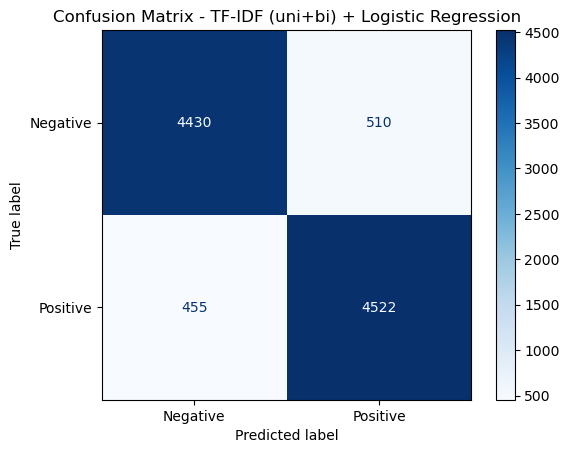


Total misclassified: 965 out of 9917

--- Sample misclassified reviews ---

True: Negative | Predicted: Positive
la lupa mannara aka werewolf woman film highli promis titl sadli film pretti far away must see fellow italian horror buff not hear say rino di silvestri film entir bad stylish moment first half actual great fun watch though fun unintent film also pro

True: Positive | Predicted: Negative
not exactli great film admir writer director tri someth littl differ film main theme fate small seemingli insignific thing greatli chang futur way remind film slide door though instead focus one random event seemingli random stuff happen repeatedli o

True: Negative | Predicted: Positive
despit huge fan fred astair ginger roger movi not year ago first saw follow fleet knew song old astair roger record ye vinyl knew noth plot unfortun song catchi ginger roger charact sweet funni cannot like bake baker tri make longtim partner continu 

True: Positive | Predicted: Negative
well well roeg touc

In [14]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

best_model = lr_grid.best_estimator_
best_preds = best_model.predict(X_test_tfidf_bigram)

# Classification report
print(classification_report(y_test, best_preds, target_names=['Negative', 'Positive']))

# Confusion matrix
cm = confusion_matrix(y_test, best_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Negative', 'Positive'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix - TF-IDF (uni+bi) + Logistic Regression')
plt.show()

# Look at some misclassified examples
X_test_reset = X_test.reset_index(drop=True)
y_test_reset = y_test.reset_index(drop=True)

misclassified_idx = np.where(best_preds != y_test_reset)[0]
print(f"\nTotal misclassified: {len(misclassified_idx)} out of {len(y_test_reset)}")

print("\n--- Sample misclassified reviews ---")
for i in misclassified_idx[:5]:
    print(f"\nTrue: {'Positive' if y_test_reset[i]==1 else 'Negative'} | Predicted: {'Positive' if best_preds[i]==1 else 'Negative'}")
    print(X_test_reset.iloc[i][:250])

In [15]:
feature_names = np.array(tfidf_bigram_vectorizer.get_feature_names_out())
coefs = best_model.coef_[0]

# Top positive and negative features
top_positive_idx = np.argsort(coefs)[-20:][::-1]
top_negative_idx = np.argsort(coefs)[:20]

print("=== Top 20 words/phrases pushing toward POSITIVE ===")
for idx in top_positive_idx:
    print(f"{feature_names[idx]:25s} : {coefs[idx]:.3f}")

print("\n=== Top 20 words/phrases pushing toward NEGATIVE ===")
for idx in top_negative_idx:
    print(f"{feature_names[idx]:25s} : {coefs[idx]:.3f}")

=== Top 20 words/phrases pushing toward POSITIVE ===
excel                     : 9.678
not disappoint            : 9.013
great                     : 8.862
perfect                   : 7.995
enjoy                     : 7.349
must see                  : 7.321
amaz                      : 7.167
hilari                    : 6.661
fun                       : 6.633
brilliant                 : 6.453
highli recommend          : 6.448
well worth                : 6.446
best                      : 6.384
subtl                     : 6.323
one best                  : 6.273
favorit                   : 6.153
superb                    : 6.003
today                     : 5.970
refresh                   : 5.950
strong                    : 5.664

=== Top 20 words/phrases pushing toward NEGATIVE ===
worst                     : -13.108
aw                        : -12.397
bore                      : -10.165
disappoint                : -9.732
wast                      : -9.337
not funni                 : -9.114


In [16]:

nb_model = nb_grid.best_estimator_
feature_names_nb = np.array(tfidf_bigram_vectorizer.get_feature_names_out())

# log P(word | positive) - log P(word | negative)
log_prob_diff = nb_model.feature_log_prob_[1] - nb_model.feature_log_prob_[0]

top_positive_idx = np.argsort(log_prob_diff)[-20:][::-1]
top_negative_idx = np.argsort(log_prob_diff)[:20]

print("=== Top 20 words/phrases pushing toward POSITIVE (Naive Bayes) ===")
for idx in top_positive_idx:
    print(f"{feature_names_nb[idx]:25s} : {log_prob_diff[idx]:.3f}")

print("\n=== Top 20 words/phrases pushing toward NEGATIVE (Naive Bayes) ===")
for idx in top_negative_idx:
    print(f"{feature_names_nb[idx]:25s} : {log_prob_diff[idx]:.3f}")

=== Top 20 words/phrases pushing toward POSITIVE (Naive Bayes) ===
well worth                : 2.214
highli recommend          : 2.131
must see                  : 1.974
matthau                   : 1.970
one best                  : 1.923
definit worth             : 1.826
cast excel                : 1.784
ponyo                     : 1.754
favorit movi              : 1.733
superb                    : 1.712
felix                     : 1.702
also great                : 1.686
flawless                  : 1.673
thoroughli enjoy          : 1.660
rori                      : 1.660
cannot wait               : 1.660
great job                 : 1.643
timeless                  : 1.632
underr                    : 1.625
act superb                : 1.623

=== Top 20 words/phrases pushing toward NEGATIVE (Naive Bayes) ===
worst movi                : -3.254
one worst                 : -2.885
worst film                : -2.844
wast time                 : -2.792
worst                     : -2.475
wast      

In [17]:
def predict_sentiment(text):
    cleaned = clean_text(text)
    processed = preprocess_text(cleaned)
    vec = tfidf_bigram_vectorizer.transform([processed])
    pred = best_model.predict(vec)[0]
    prob = best_model.predict_proba(vec)[0]
    return ('Positive' if pred==1 else 'Negative'), prob

# Try it
print(predict_sentiment("This movie was absolutely wonderful, the acting was superb!"))
print(predict_sentiment("Waste of time, I regret watching this."))

('Positive', array([0.03122557, 0.96877443]))
('Negative', array([0.99885711, 0.00114289]))


In [18]:
import joblib

# Save the trained Logistic Regression model
joblib.dump(best_model, 'sentiment_model.pkl')

# Save the TF-IDF (uni+bi) vectorizer used with it
joblib.dump(tfidf_bigram_vectorizer, 'tfidf_vectorizer.pkl')

print("Model and vectorizer saved successfully!")


Model and vectorizer saved successfully!


In [19]:
import os
print(os.getcwd())

C:\Users\Ananya


In [20]:
import os
print(os.path.abspath('sentiment_model.pkl'))

C:\Users\Ananya\sentiment_model.pkl


In [21]:
print(df['review'].str.contains('’').sum())

26


In [22]:
# Find rows where the raw review has a curly apostrophe
curly_rows = df[df['review'].str.contains('’')]

# Show a before/after for a few of them
for i in range(min(3, len(curly_rows))):
    raw = curly_rows['review'].iloc[i]
    cleaned = clean_text(raw)
    print("RAW:", raw[:150])
    print("CLEANED:", cleaned[:150])
    print()

RAW: Tell the truth I’m a bit stun to see all these positive review by so many people, which is also the main reason why I actually decide to see this movi
CLEANED: tell the truth i am a bit stun to see all these positive review by so many people which is also the main reason why i actually decide to see this movi

RAW: Manipulative drama about a glamorous model (Margaux Hemingway) who is raped by a geeky but unbalanced musician (Chris Sarandon) – to whom she had been
CLEANED: manipulative drama about a glamorous model margaux hemingway who is raped by a geeky but unbalanced musician chris sarandon to whom she had been intro

RAW: First, let me mention the fact that, in spite of its title («Stories», in plural), there is only ONE Kitchen Story. As to whether Isak died or not at 
CLEANED: first let me mention the fact that in spite of its title stories in plural there is only one kitchen story as to whether isak died or not at the end i



In [23]:
import re

# Search specifically for curly-apostrophe NEGATION contractions
negation_pattern = "wasn’t|didn’t|isn’t|aren’t|weren’t|doesn’t|don’t|couldn’t|shouldn’t|wouldn’t|won’t|can’t"

negation_rows = df[df['review'].str.contains(negation_pattern, regex=True)]

print(f"Rows with curly-apostrophe negation contractions: {len(negation_rows)}")

for i in range(min(5, len(negation_rows))):
    raw = negation_rows['review'].iloc[i]
    cleaned = clean_text(raw)
    print("RAW:", raw[:150])
    print("CLEANED:", cleaned[:150])
    print()

Rows with curly-apostrophe negation contractions: 12
RAW: Rather foolish attempt at a Hitchcock-type mystery-thriller, improbably exchanging espionage for archaeology and based on the Robin Cook novel; incide
CLEANED: rather foolish attempt at a hitchcock type mystery thriller improbably exchanging espionage for archaeology and based on the robin cook novel incident

RAW: Following his role in the fine caper SEVEN THIEVES (1960) – which I’ve watched several years back – Edward G. Robinson seemed to be stuck playing elde
CLEANED: following his role in the fine caper seven thieves which i have watched several years back edward g robinson seemed to be stuck playing elderly crimin

RAW: I had never read much about (or even seen stills of) the six-man British comedy group The Crazy Gang, but my positive experiences with their contempor
CLEANED: i had never read much about or even seen stills of the six man british comedy group the crazy gang but my positive experiences with their contempora

In [24]:
import re

negation_pattern = "wasn’t|didn’t|isn’t|aren’t|weren’t|doesn’t|don’t|couldn’t|shouldn’t|wouldn’t|won’t|can’t"
negation_rows = df[df['review'].str.contains(negation_pattern, regex=True)]

broken_count = 0

for i in range(len(negation_rows)):
    raw = negation_rows['review'].iloc[i]
    cleaned = clean_text(raw)
    
    # Look for broken fragments like "wasn t", "didn t", "isn t" etc.
    if re.search(r'\b(wasn|didn|isn|aren|weren|doesn|don|couldn|shouldn|wouldn|won|can)\s+t\b', cleaned):
        broken_count += 1
        print("STILL BROKEN:")
        print("RAW:", raw)
        print("CLEANED:", cleaned)
        print()

print(f"\nTotal broken out of {len(negation_rows)} curly-negation rows: {broken_count}")


Total broken out of 12 curly-negation rows: 0


In [25]:
joblib.dump(best_model, 'sentiment_model.pkl')
joblib.dump(tfidf_bigram_vectorizer, 'tfidf_vectorizer.pkl')
print("Model and vectorizer saved successfully!")

Model and vectorizer saved successfully!
